In [ ]:
 !pip install -q safetensors pillow

from google.colab import drive
drive.mount("/content/drive")

import os
import sys
import gc
import shutil
import subprocess
import importlib
from collections import Counter

import numpy as np
import torch
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

from PIL import Image
from safetensors.torch import load_file as st_load_file

print("TensorFlow:", tf.__version__)
print("PyTorch   :", torch.__version__)
print("NumPy     :", np.__version__)

Mounted at /content/drive
TensorFlow: 2.20.0
PyTorch   : 2.11.0+cpu
NumPy     : 2.0.2


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/interns"

TAESD_PY    = os.path.join(PROJECT_DIR, "taesd.py")
CKPT_PATH   = os.path.join(PROJECT_DIR, "taesd3_decoder.pth")
LATENT_PATH = os.path.join(PROJECT_DIR, "sample_1_out.latent")

SPLIT_DIR = os.path.join(PROJECT_DIR, "taesd3_split_uint8")
os.makedirs(SPLIT_DIR, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("SPLIT_DIR  :", SPLIT_DIR)

required = {
    "taesd.py": TAESD_PY,
    "taesd3_decoder.pth": CKPT_PATH,
    "sample_1_out.latent": LATENT_PATH,
}

for name, path in required.items():
    print(name, "exists:", os.path.exists(path), path)
    if not os.path.exists(path):
        raise FileNotFoundError(path)

PROJECT_DIR: /content/drive/MyDrive/interns
SPLIT_DIR  : /content/drive/MyDrive/interns/taesd3_split_uint8
taesd.py exists: True /content/drive/MyDrive/interns/taesd.py
taesd3_decoder.pth exists: True /content/drive/MyDrive/interns/taesd3_decoder.pth
sample_1_out.latent exists: True /content/drive/MyDrive/interns/sample_1_out.latent


In [ ]:
if "taesd" in sys.modules:
    del sys.modules["taesd"]

sys.path.insert(0, PROJECT_DIR)

import taesd
importlib.reload(taesd)

print("✅ Imported taesd from:", taesd.__file__)

✅ Imported taesd from: /content/drive/MyDrive/interns/taesd.py


In [ ]:
def load_latent(path):
    data = st_load_file(path, device="cpu")

    if "latent_tensor" not in data:
        raise KeyError(f"latent_tensor not found. Keys: {list(data.keys())}")

    z = data["latent_tensor"].float().numpy().astype(np.float32)

    print("Latent shape:", z.shape)
    print("Latent dtype :", z.dtype)
    print("Latent range :", z.min(), "to", z.max())

    if z.shape != (1, 16, 64, 64):
        raise ValueError(f"Expected latent [1,16,64,64], got {z.shape}")

    return z


z_np = load_latent(LATENT_PATH)

print("✅ z_np loaded correctly")

Latent shape: (1, 16, 64, 64)
Latent dtype : float32
Latent range : -2.4265351 to 2.140113
✅ z_np loaded correctly


In [ ]:
def load_latent(path):
    data = st_load_file(path, device="cpu")

    if "latent_tensor" not in data:
        raise KeyError(f"latent_tensor not found. Keys: {list(data.keys())}")

    z = data["latent_tensor"].float().numpy().astype(np.float32)

    print("Latent shape:", z.shape)
    print("Latent dtype :", z.dtype)
    print("Latent range :", z.min(), "to", z.max())

    if z.shape != (1, 16, 64, 64):
        raise ValueError(f"Expected latent [1,16,64,64], got {z.shape}")

    return z


z_np = load_latent(LATENT_PATH)

print("✅ z_np loaded correctly")

Latent shape: (1, 16, 64, 64)
Latent dtype : float32
Latent range : -2.4265351 to 2.140113
✅ z_np loaded correctly


In [ ]:
state = torch.load(
    CKPT_PATH,
    map_location="cpu",
    weights_only=False
)

first_conv_key = None
first_conv_weight = None

for k, v in state.items():
    if hasattr(v, "shape") and len(v.shape) == 4:
        first_conv_key = k
        first_conv_weight = v
        break

print("First conv:", first_conv_key, first_conv_weight.shape)

if tuple(first_conv_weight.shape) != (64, 16, 3, 3):
    raise ValueError(f"Wrong checkpoint. Expected [64,16,3,3], got {first_conv_weight.shape}")

teacher = taesd.Decoder(latent_channels=16)
teacher.load_state_dict(state)
teacher.eval()

print("✅ PyTorch teacher loaded")

First conv: 1.weight torch.Size([64, 16, 3, 3])
✅ PyTorch teacher loaded


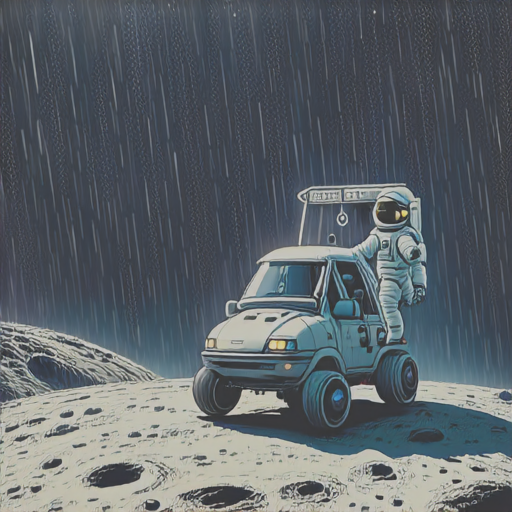

✅ Teacher preview saved: /content/drive/MyDrive/interns/teacher_preview.png


In [ ]:
z_torch = torch.from_numpy(z_np).float() * 2.0

with torch.no_grad():
    teacher_raw = teacher(z_torch)
    teacher_img_tensor = teacher_raw.mul(0.5).add(0.25).clamp(0, 1)

teacher_img = teacher_img_tensor[0].permute(1, 2, 0).cpu().numpy()
teacher_img_u8 = (teacher_img * 255).round().astype(np.uint8)

teacher_preview_path = os.path.join(PROJECT_DIR, "teacher_preview.png")
Image.fromarray(teacher_img_u8).save(teacher_preview_path)

display(Image.fromarray(teacher_img_u8))

print("✅ Teacher preview saved:", teacher_preview_path)

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

def exact_block(x, channels, name):
    skip = x

    h = layers.Conv2D(
        channels, 3,
        padding="same",
        use_bias=True,
        name=f"{name}_conv0"
    )(x)
    h = layers.ReLU(name=f"{name}_relu0")(h)

    h = layers.Conv2D(
        channels, 3,
        padding="same",
        use_bias=True,
        name=f"{name}_conv2"
    )(h)
    h = layers.ReLU(name=f"{name}_relu2")(h)

    h = layers.Conv2D(
        channels, 3,
        padding="same",
        use_bias=True,
        name=f"{name}_conv4"
    )(h)

    h = layers.Add(name=f"{name}_add")([h, skip])
    h = layers.ReLU(name=f"{name}_fuse_relu")(h)

    return h


def build_exact_taesd3_full():
    C = 64

    inp = keras.Input(
        shape=(64, 64, 16),
        batch_size=1,
        name="latent_input",
        dtype=tf.float32
    )

    # PyTorch layer 1
    x = layers.Conv2D(C, 3, padding="same", use_bias=True, name="model_1")(inp)

    # PyTorch blocks 3,4,5
    x = exact_block(x, C, "model_3")
    x = exact_block(x, C, "model_4")
    x = exact_block(x, C, "model_5")

    # PyTorch layer 6: upsample 64 -> 128
    x = layers.Resizing(128, 128, interpolation="nearest", name="model_6")(x)

    # PyTorch layer 7
    x = layers.Conv2D(C, 3, padding="same", use_bias=True, name="model_7")(x)

    # PyTorch blocks 8,9,10
    x = exact_block(x, C, "model_8")
    x = exact_block(x, C, "model_9")
    x = exact_block(x, C, "model_10")

    # PyTorch layer 11: upsample 128 -> 256
    x = layers.Resizing(256, 256, interpolation="nearest", name="model_11")(x)

    # PyTorch layer 12
    x = layers.Conv2D(C, 3, padding="same", use_bias=True, name="model_12")(x)

    # PyTorch blocks 13,14,15
    x = exact_block(x, C, "model_13")
    x = exact_block(x, C, "model_14")
    x = exact_block(x, C, "model_15")

    # PyTorch layer 16: upsample 256 -> 512
    x = layers.Resizing(512, 512, interpolation="nearest", name="model_16")(x)

    # PyTorch layer 17
    x = layers.Conv2D(C, 3, padding="same", use_bias=True, name="model_17")(x)

    # PyTorch block 18
    x = exact_block(x, C, "model_18")

    # PyTorch layer 19 raw output
    out = layers.Conv2D(3, 3, padding="same", use_bias=True, name="model_19")(x)

    return keras.Model(
        inputs=inp,
        outputs=out,
        name="TAESD3_Exact_Full_Raw"
    )


exact_student = build_exact_taesd3_full()
exact_student.summary(line_length=120)

print("✅ Exact full Keras model built")

Model: "TAESD3_Exact_Full_Raw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ latent_input (InputLayer)         │ (1, 64, 64, 16)              │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_1 (Conv2D)                  │ (1, 64, 64, 64)              │             9,280 │ latent_input[0][0]        
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_3_conv0 (Conv2D)            │ (1, 64, 64, 64)              │            36,928 │ model_1[0][0]             
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_3_relu0 (ReLU)              │ (1, 64, 64, 64)              │                 0 │ model_3_conv0[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_3_conv2 (Conv2D)            │ (1, 64, 64, 64)              │            36,928 │ model_3_relu0[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_3_relu2 (ReLU)              │ (1, 64, 64, 64)              │                 0 │ model_3_conv2[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_3_conv4 (Conv2D)            │ (1, 64, 64, 64)              │            36,928 │ model_3_relu2[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_3_add (Add)                 │ (1, 64, 64, 64)              │                 0 │ model_3_conv4[0][0],      
│                                   │                              │                   │ model_1[0][0]             
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_3_fuse_relu (ReLU)          │ (1, 64, 64, 64)              │                 0 │ model_3_add[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_4_conv0 (Conv2D)            │ (1, 64, 64, 64)              │            36,928 │ model_3_fuse_relu[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_4_relu0 (ReLU)              │ (1, 64, 64, 64)              │                 0 │ model_4_conv0[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_4_conv2 (Conv2D)            │ (1, 64, 64, 64)              │            36,928 │ model_4_relu0[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_4_relu2 (ReLU)              │ (1, 64, 64, 64)              │                 0 │ model_4_conv2[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_4_conv4 (Conv2D)            │ (1, 64, 64, 64)              │            36,928 │ model_4_relu2[0][0]       
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ model_4_add (Add)                 │ (1, 64, 64, 64)              │                 0 │ model_4_conv4[0][0],      
│                                   │                              │                   │ model_3_fuse_relu[0][0]   
├───────────────────────────────────┼───────────────────

 Total params: 1,229,635 (4.69 MB)

 Trainable params: 1,229,635 (4.69 MB)

 Non-trainable params: 0 (0.00 B)

✅ Exact full Keras model built


In [ ]:
pt_convs = [
    m for m in teacher.modules()
    if isinstance(m, torch.nn.Conv2d)
]

keras_convs = [
    l for l in exact_student.layers
    if isinstance(l, tf.keras.layers.Conv2D)
]

print("PyTorch Conv2d:", len(pt_convs))
print("Keras Conv2D :", len(keras_convs))

if len(pt_convs) != len(keras_convs):
    raise ValueError(f"Conv count mismatch: PyTorch={len(pt_convs)}, Keras={len(keras_convs)}")

for i, (pt_conv, k_conv) in enumerate(zip(pt_convs, keras_convs)):
    pt_shape = tuple(pt_conv.weight.shape)
    expected = (pt_shape[2], pt_shape[3], pt_shape[1], pt_shape[0])
    actual = k_conv.get_weights()[0].shape

    print(f"{i:02d} {k_conv.name:20s} expected {expected} actual {actual}")

    if expected != actual:
        raise ValueError(f"Mismatch at {k_conv.name}: expected {expected}, got {actual}")

print("✅ Conv count and shapes match")

PyTorch Conv2d: 35
Keras Conv2D : 35
00 model_1              expected (3, 3, 16, 64) actual (3, 3, 16, 64)
01 model_3_conv0        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
02 model_3_conv2        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
03 model_3_conv4        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
04 model_4_conv0        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
05 model_4_conv2        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
06 model_4_conv4        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
07 model_5_conv0        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
08 model_5_conv2        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
09 model_5_conv4        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
10 model_7              expected (3, 3, 64, 64) actual (3, 3, 64, 64)
11 model_8_conv0        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
12 model_8_conv2        expected (3, 3, 64, 64) actual (3, 3, 64, 64)
13 model_8_conv4        expected (3, 3, 64, 64) actua

In [ ]:
for i, (pt_conv, k_conv) in enumerate(zip(pt_convs, keras_convs)):
    w_pt = pt_conv.weight.detach().cpu().numpy()
    w_tf = np.transpose(w_pt, (2, 3, 1, 0))

    keras_weights = k_conv.get_weights()

    if len(keras_weights) == 2:
        if pt_conv.bias is not None:
            b_pt = pt_conv.bias.detach().cpu().numpy()
        else:
            b_pt = np.zeros((w_tf.shape[-1],), dtype=np.float32)

        k_conv.set_weights([w_tf, b_pt])
    else:
        k_conv.set_weights([w_tf])

    print(f"Copied {i:02d}: {k_conv.name}")

print("✅ All PyTorch weights copied into Keras")

Copied 00: model_1
Copied 01: model_3_conv0
Copied 02: model_3_conv2
Copied 03: model_3_conv4
Copied 04: model_4_conv0
Copied 05: model_4_conv2
Copied 06: model_4_conv4
Copied 07: model_5_conv0
Copied 08: model_5_conv2
Copied 09: model_5_conv4
Copied 10: model_7
Copied 11: model_8_conv0
Copied 12: model_8_conv2
Copied 13: model_8_conv4
Copied 14: model_9_conv0
Copied 15: model_9_conv2
Copied 16: model_9_conv4
Copied 17: model_10_conv0
Copied 18: model_10_conv2
Copied 19: model_10_conv4
Copied 20: model_12
Copied 21: model_13_conv0
Copied 22: model_13_conv2
Copied 23: model_13_conv4
Copied 24: model_14_conv0
Copied 25: model_14_conv2
Copied 26: model_14_conv4
Copied 27: model_15_conv0
Copied 28: model_15_conv2
Copied 29: model_15_conv4
Copied 30: model_17
Copied 31: model_18_conv0
Copied 32: model_18_conv2
Copied 33: model_18_conv4
Copied 34: model_19
✅ All PyTorch weights copied into Keras


In [ ]:
KERAS_FULL_PATH = os.path.join(PROJECT_DIR, "taesd3_exact_full_copied_weights_raw.keras")

exact_student.save(KERAS_FULL_PATH)

print("✅ Saved:", KERAS_FULL_PATH)

✅ Saved: /content/drive/MyDrive/interns/taesd3_exact_full_copied_weights_raw.keras


In [ ]:
def build_part1():
    C = 64
    inp = keras.Input(shape=(64, 64, 16), batch_size=1, name="part1_input", dtype=tf.float32)

    x = layers.Conv2D(C, 3, padding="same", use_bias=True, name="model_1")(inp)

    x = exact_block(x, C, "model_3")
    x = exact_block(x, C, "model_4")
    x = exact_block(x, C, "model_5")

    return keras.Model(inp, x, name="taesd3_part1_64")


def build_part2():
    C = 64
    inp = keras.Input(shape=(128, 128, 64), batch_size=1, name="part2_input", dtype=tf.float32)

    x = layers.Conv2D(C, 3, padding="same", use_bias=True, name="model_7")(inp)

    x = exact_block(x, C, "model_8")
    x = exact_block(x, C, "model_9")
    x = exact_block(x, C, "model_10")

    return keras.Model(inp, x, name="taesd3_part2_128")


def build_part3():
    C = 64
    inp = keras.Input(shape=(256, 256, 64), batch_size=1, name="part3_input", dtype=tf.float32)

    x = layers.Conv2D(C, 3, padding="same", use_bias=True, name="model_12")(inp)

    x = exact_block(x, C, "model_13")
    x = exact_block(x, C, "model_14")
    x = exact_block(x, C, "model_15")

    return keras.Model(inp, x, name="taesd3_part3_256")


def build_part4():
    C = 64
    inp = keras.Input(shape=(512, 512, 64), batch_size=1, name="part4_input", dtype=tf.float32)

    x = layers.Conv2D(C, 3, padding="same", use_bias=True, name="model_17")(inp)

    x = exact_block(x, C, "model_18")

    out = layers.Conv2D(3, 3, padding="same", use_bias=True, name="model_19")(x)

    return keras.Model(inp, out, name="taesd3_part4_512_raw")


part1 = build_part1()
part2 = build_part2()
part3 = build_part3()
part4 = build_part4()

print("✅ Split models built")

✅ Split models built


In [ ]:
def copy_weights_by_name(src_model, dst_model):
    copied = 0
    skipped = []

    for layer in dst_model.layers:
        if len(layer.get_weights()) == 0:
            continue

        try:
            src_layer = src_model.get_layer(layer.name)
            layer.set_weights(src_layer.get_weights())
            copied += 1
            print("Copied:", layer.name)
        except Exception as e:
            skipped.append((layer.name, str(e)))

    print("Copied weighted layers:", copied)

    if skipped:
        print("Skipped:")
        for name, err in skipped:
            print(name, "->", err)


print("Part 1")
copy_weights_by_name(exact_student, part1)

print("\nPart 2")
copy_weights_by_name(exact_student, part2)

print("\nPart 3")
copy_weights_by_name(exact_student, part3)

print("\nPart 4")
copy_weights_by_name(exact_student, part4)

Part 1
Copied: model_1
Copied: model_3_conv0
Copied: model_3_conv2
Copied: model_3_conv4
Copied: model_4_conv0
Copied: model_4_conv2
Copied: model_4_conv4
Copied: model_5_conv0
Copied: model_5_conv2
Copied: model_5_conv4
Copied weighted layers: 10

Part 2
Copied: model_7
Copied: model_8_conv0
Copied: model_8_conv2
Copied: model_8_conv4
Copied: model_9_conv0
Copied: model_9_conv2
Copied: model_9_conv4
Copied: model_10_conv0
Copied: model_10_conv2
Copied: model_10_conv4
Copied weighted layers: 10

Part 3
Copied: model_12
Copied: model_13_conv0
Copied: model_13_conv2
Copied: model_13_conv4
Copied: model_14_conv0
Copied: model_14_conv2
Copied: model_14_conv4
Copied: model_15_conv0
Copied: model_15_conv2
Copied: model_15_conv4
Copied weighted layers: 10

Part 4
Copied: model_17
Copied: model_18_conv0
Copied: model_18_conv2
Copied: model_18_conv4
Copied: model_19
Copied weighted layers: 5


In [ ]:
# =====================================================
# CREATE x0 INPUT FOR KERAS/SPLIT MODEL
# z_np is [1,16,64,64]
# x0 is [1,64,64,16]
# =====================================================

import numpy as np

if "z_np" not in globals():
    raise NameError("z_np is not defined. Run the latent loading cell first.")

print("z_np shape:", z_np.shape)

if z_np.shape != (1, 16, 64, 64):
    raise ValueError(f"Expected z_np [1,16,64,64], got {z_np.shape}")

# Same preprocessing used for TAESD3
x0 = np.transpose(z_np * 2.0, (0, 2, 3, 1)).astype(np.float32)

print("✅ x0 created")
print("x0 shape:", x0.shape)
print("x0 dtype:", x0.dtype)
print("x0 range:", x0.min(), "to", x0.max())

z_np shape: (1, 16, 64, 64)
✅ x0 created
x0 shape: (1, 64, 64, 16)
x0 dtype: float32
x0 range: -4.8530703 to 4.280226


MAE : 0.0
MSE : 0.0
PSNR: 120.0 dB


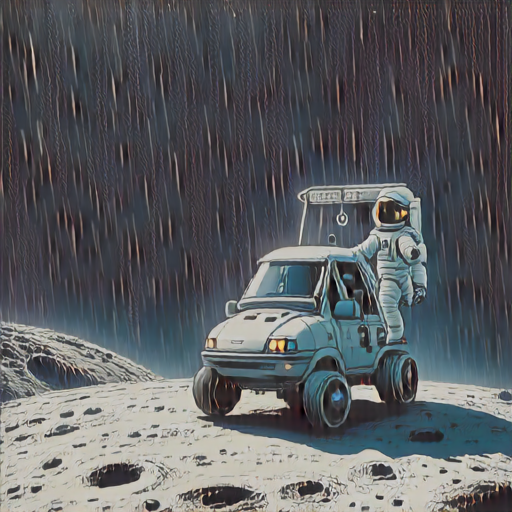

✅ Saved: /content/drive/MyDrive/interns/taesd3_split_uint8/split_float_preview.png


In [ ]:
def resize_nearest_2x_np(x):
    x = np.repeat(x, 2, axis=1)
    x = np.repeat(x, 2, axis=2)
    return x.astype(np.float32)


full_raw = exact_student.predict(x0, verbose=0)

y1 = part1.predict(x0, verbose=0)
r1 = resize_nearest_2x_np(y1)

y2 = part2.predict(r1, verbose=0)
r2 = resize_nearest_2x_np(y2)

y3 = part3.predict(r2, verbose=0)
r3 = resize_nearest_2x_np(y3)

split_raw = part4.predict(r3, verbose=0)

mse = np.mean((full_raw - split_raw) ** 2)
mae = np.mean(np.abs(full_raw - split_raw))
psnr = 10 * np.log10(1.0 / (mse + 1e-12))

print("MAE :", mae)
print("MSE :", mse)
print("PSNR:", psnr, "dB")

split_img = np.clip(split_raw[0] * 0.5 + 0.25, 0, 1)
split_img_u8 = (split_img * 255).round().astype(np.uint8)

display(Image.fromarray(split_img_u8))

split_preview = os.path.join(SPLIT_DIR, "split_float_preview.png")
Image.fromarray(split_img_u8).save(split_preview)

print("✅ Saved:", split_preview)

In [ ]:
N_CALIB = 32
rng = np.random.default_rng(42)

calib1 = []
calib2 = []
calib3 = []
calib4 = []

base = x0.copy()

for i in range(N_CALIB):
    noise = rng.normal(0, 0.03, base.shape).astype(np.float32)

    x1 = base + noise

    p1 = part1.predict(x1, verbose=0)
    x2 = resize_nearest_2x_np(p1)

    p2 = part2.predict(x2, verbose=0)
    x3 = resize_nearest_2x_np(p2)

    p3 = part3.predict(x3, verbose=0)
    x4 = resize_nearest_2x_np(p3)

    calib1.append(x1[0])
    calib2.append(x2[0])
    calib3.append(x3[0])
    calib4.append(x4[0])

    print(f"Prepared {i+1}/{N_CALIB}")

calib1 = np.stack(calib1).astype(np.float32)
calib2 = np.stack(calib2).astype(np.float32)
calib3 = np.stack(calib3).astype(np.float32)
calib4 = np.stack(calib4).astype(np.float32)

CALIB1 = os.path.join(SPLIT_DIR, "calib_part1.npy")
CALIB2 = os.path.join(SPLIT_DIR, "calib_part2.npy")
CALIB3 = os.path.join(SPLIT_DIR, "calib_part3.npy")
CALIB4 = os.path.join(SPLIT_DIR, "calib_part4.npy")

np.save(CALIB1, calib1)
np.save(CALIB2, calib2)
np.save(CALIB3, calib3)
np.save(CALIB4, calib4)

print(CALIB1, calib1.shape)
print(CALIB2, calib2.shape)
print(CALIB3, calib3.shape)
print(CALIB4, calib4.shape)

Prepared 1/32
Prepared 2/32
Prepared 3/32
Prepared 4/32
Prepared 5/32
Prepared 6/32
Prepared 7/32
Prepared 8/32
Prepared 9/32
Prepared 10/32
Prepared 11/32
Prepared 12/32
Prepared 13/32
Prepared 14/32
Prepared 15/32
Prepared 16/32
Prepared 17/32
Prepared 18/32
Prepared 19/32
Prepared 20/32
Prepared 21/32
Prepared 22/32
Prepared 23/32
Prepared 24/32
Prepared 25/32
Prepared 26/32
Prepared 27/32
Prepared 28/32
Prepared 29/32
Prepared 30/32
Prepared 31/32
Prepared 32/32
/content/drive/MyDrive/interns/taesd3_split_uint8/calib_part1.npy (32, 64, 64, 16)
/content/drive/MyDrive/interns/taesd3_split_uint8/calib_part2.npy (32, 128, 128, 64)
/content/drive/MyDrive/interns/taesd3_split_uint8/calib_part3.npy (32, 256, 256, 64)
/content/drive/MyDrive/interns/taesd3_split_uint8/calib_part4.npy (32, 512, 512, 64)


In [ ]:
def convert_part_to_uint8_tflite(model, input_shape, calib_npy, output_path):
    dummy = tf.zeros(input_shape, dtype=tf.float32)
    _ = model(dummy, training=False)

    @tf.function(
        input_signature=[
            tf.TensorSpec(
                shape=input_shape,
                dtype=tf.float32,
                name="input"
            )
        ]
    )
    def serving_fn(x):
        return model(x, training=False)

    concrete_func = serving_fn.get_concrete_function()

    print("Freezing:", model.name)
    frozen_func = convert_variables_to_constants_v2(concrete_func)

    calib = np.load(calib_npy).astype(np.float32)

    print("Calibration:", calib.shape, calib.min(), calib.max())

    def representative_dataset():
        for i in range(len(calib)):
            yield [calib[i:i+1]]

    converter = tf.lite.TFLiteConverter.from_concrete_functions([frozen_func])

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset

    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]

    converter.inference_input_type = tf.uint8
    converter.inference_output_type = tf.uint8

    converter.experimental_new_converter = True

    print("Converting:", output_path)
    tflite_model = converter.convert()

    with open(output_path, "wb") as f:
        f.write(tflite_model)

    print("✅ Saved:", output_path)
    print("Size MB:", os.path.getsize(output_path) / 1024 / 1024)

    return output_path

In [ ]:
PART1_TFLITE = os.path.join(SPLIT_DIR, "taesd3_part1_64_uint8.tflite")
PART2_TFLITE = os.path.join(SPLIT_DIR, "taesd3_part2_128_uint8.tflite")
PART3_TFLITE = os.path.join(SPLIT_DIR, "taesd3_part3_256_uint8.tflite")
PART4_TFLITE = os.path.join(SPLIT_DIR, "taesd3_part4_512_uint8.tflite")

convert_part_to_uint8_tflite(
    part1,
    [1, 64, 64, 16],
    CALIB1,
    PART1_TFLITE
)

convert_part_to_uint8_tflite(
    part2,
    [1, 128, 128, 64],
    CALIB2,
    PART2_TFLITE
)

convert_part_to_uint8_tflite(
    part3,
    [1, 256, 256, 64],
    CALIB3,
    PART3_TFLITE
)

convert_part_to_uint8_tflite(
    part4,
    [1, 512, 512, 64],
    CALIB4,
    PART4_TFLITE
)

Freezing: taesd3_part1_64


Calibration: (32, 64, 64, 16) -4.9235682 4.3660707
Converting: /content/drive/MyDrive/interns/taesd3_split_uint8/taesd3_part1_64_uint8.tflite


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ Saved: /content/drive/MyDrive/interns/taesd3_split_uint8/taesd3_part1_64_uint8.tflite
Size MB: 0.34859466552734375
Freezing: taesd3_part2_128


Calibration: (32, 128, 128, 64) 0.0 5.9370337
Converting: /content/drive/MyDrive/interns/taesd3_split_uint8/taesd3_part2_128_uint8.tflite
✅ Saved: /content/drive/MyDrive/interns/taesd3_split_uint8/taesd3_part2_128_uint8.tflite
Size MB: 0.375030517578125
Freezing: taesd3_part3_256


Calibration: (32, 256, 256, 64) 0.0 10.83623
Converting: /content/drive/MyDrive/interns/taesd3_split_uint8/taesd3_part3_256_uint8.tflite
✅ Saved: /content/drive/MyDrive/interns/taesd3_split_uint8/taesd3_part3_256_uint8.tflite
Size MB: 0.37493896484375
Freezing: taesd3_part4_512_raw


Calibration: (32, 512, 512, 64) 0.0 8.589185
Converting: /content/drive/MyDrive/interns/taesd3_split_uint8/taesd3_part4_512_uint8.tflite
✅ Saved: /content/drive/MyDrive/interns/taesd3_split_uint8/taesd3_part4_512_uint8.tflite
Size MB: 0.152618408203125


'/content/drive/MyDrive/interns/taesd3_split_uint8/taesd3_part4_512_uint8.tflite'

In [ ]:
def check_tflite(path):
    print("\n" + "=" * 80)
    print("Checking:", os.path.basename(path))
    print("=" * 80)

    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()

    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]
    tensors = interpreter.get_tensor_details()

    fp32 = [t for t in tensors if t["dtype"] == np.float32]
    uint8 = [t for t in tensors if t["dtype"] == np.uint8]
    int8 = [t for t in tensors if t["dtype"] == np.int8]
    int32 = [t for t in tensors if t["dtype"] == np.int32]

    print("Input :", inp["shape"], inp["dtype"], inp["quantization"])
    print("Output:", out["shape"], out["dtype"], out["quantization"])

    print("UINT8 tensors:", len(uint8))
    print("INT8 tensors :", len(int8))
    print("INT32 tensors:", len(int32))
    print("FP32 tensors :", len(fp32))

    ops = interpreter._get_ops_details()
    op_counts = Counter(op["op_name"] for op in ops)

    print("\nOps:")
    for op, count in sorted(op_counts.items()):
        print(f"{op:35s} x{count}")

    if inp["dtype"] == np.uint8 and out["dtype"] == np.uint8 and len(fp32) == 0:
        print("✅ UINT8 I/O and FP32=0")
    else:
        print("❌ Quantization check failed")

    if "TILE" in op_counts:
        print("❌ TILE found")
    else:
        print("✅ TILE not found")

    return op_counts


check_tflite(PART1_TFLITE)
check_tflite(PART2_TFLITE)
check_tflite(PART3_TFLITE)
check_tflite(PART4_TFLITE)


Checking: taesd3_part1_64_uint8.tflite
Input : [ 1 64 64 16] <class 'numpy.uint8'> (0.036429956555366516, 135)
Output: [ 1 64 64 64] <class 'numpy.uint8'> (0.023282483220100403, 0)
UINT8 tensors: 2
INT8 tensors : 24
INT32 tensors: 10
FP32 tensors : 0

Ops:
ADD                                 x3
CONV_2D                             x10
DELEGATE                            x1
QUANTIZE                            x2
✅ UINT8 I/O and FP32=0
✅ TILE not found

Checking: taesd3_part2_128_uint8.tflite
Input : [  1 128 128  64] <class 'numpy.uint8'> (0.023282485082745552, 0)
Output: [  1 128 128  64] <class 'numpy.uint8'> (0.042495012283325195, 0)
UINT8 tensors: 2
INT8 tensors : 24
INT32 tensors: 10
FP32 tensors : 0

Ops:
ADD                                 x3
CONV_2D                             x10
DELEGATE                            x1
QUANTIZE                            x2
✅ UINT8 I/O and FP32=0
✅ TILE not found

Checking: taesd3_part3_256_uint8.tflite
Input : [  1 256 256  64] <class 'numpy.ui

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Counter({'QUANTIZE': 2, 'CONV_2D': 5, 'ADD': 1, 'DELEGATE': 1})


Loaded: taesd3_part1_64_uint8.tflite
Input : [ 1 64 64 16] <class 'numpy.uint8'> (0.036429956555366516, 135)
Output: [ 1 64 64 64] <class 'numpy.uint8'> (0.023282483220100403, 0)

Loaded: taesd3_part2_128_uint8.tflite
Input : [  1 128 128  64] <class 'numpy.uint8'> (0.023282485082745552, 0)
Output: [  1 128 128  64] <class 'numpy.uint8'> (0.042495012283325195, 0)

Loaded: taesd3_part3_256_uint8.tflite
Input : [  1 256 256  64] <class 'numpy.uint8'> (0.04249501973390579, 0)
Output: [  1 256 256  64] <class 'numpy.uint8'> (0.03368307650089264, 0)

Loaded: taesd3_part4_512_uint8.tflite
Input : [  1 512 512  64] <class 'numpy.uint8'> (0.03368307650089264, 0)
Output: [  1 512 512   3] <class 'numpy.uint8'> (0.008502223528921604, 76)

Initial input x0: (1, 64, 64, 16) -4.8530703 4.280226

========== TFLITE SPLIT OUTPUT ==========
Part1 output: (1, 64, 64, 64) 0.0 5.890468
Part2 output: (1, 128, 128, 64) 0.0 10.581258
Part3 output: (1, 256, 256, 64) 0.0 8.488135
Part4 raw output: (1, 512, 51

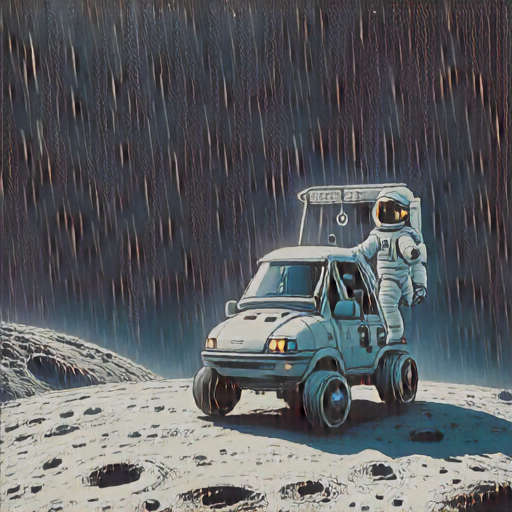

✅ Saved TFLite generated image: /content/drive/MyDrive/interns/taesd3_split_uint8/split_tflite_uint8_output.png


In [ ]:
# =====================================================
# RUN SPLIT TFLITE UINT8 PIPELINE AND GENERATE IMAGE
# =====================================================

import numpy as np
import tensorflow as tf
from PIL import Image
import os
import time

def load_tflite(path):
    interpreter = tf.lite.Interpreter(model_path=path)
    interpreter.allocate_tensors()

    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]

    print("\nLoaded:", os.path.basename(path))
    print("Input :", inp["shape"], inp["dtype"], inp["quantization"])
    print("Output:", out["shape"], out["dtype"], out["quantization"])

    return interpreter, inp, out


def quantize_uint8(x_fp32, input_detail):
    scale, zp = input_detail["quantization"]

    if scale == 0:
        raise ValueError("Input quantization scale is 0")

    x_q = np.round(x_fp32 / scale + zp)
    x_q = np.clip(x_q, 0, 255).astype(np.uint8)

    return x_q


def dequantize_uint8(x_q, output_detail):
    scale, zp = output_detail["quantization"]

    return (x_q.astype(np.float32) - zp) * scale


def run_tflite(interpreter, inp, out, x_fp32):
    # Quantize float input to uint8
    x_q = quantize_uint8(x_fp32, inp)

    interpreter.set_tensor(inp["index"], x_q)

    t0 = time.perf_counter()
    interpreter.invoke()
    t1 = time.perf_counter()

    y_q = interpreter.get_tensor(out["index"])

    # Dequantize uint8 output back to float32
    y_fp32 = dequantize_uint8(y_q, out)

    latency_ms = (t1 - t0) * 1000

    return y_fp32, latency_ms


def resize_nearest_2x_np(x):
    x = np.repeat(x, 2, axis=1)
    x = np.repeat(x, 2, axis=2)
    return x.astype(np.float32)


# -----------------------------------------------------
# Load all 4 TFLite models
# -----------------------------------------------------

i1, in1, out1 = load_tflite(PART1_TFLITE)
i2, in2, out2 = load_tflite(PART2_TFLITE)
i3, in3, out3 = load_tflite(PART3_TFLITE)
i4, in4, out4 = load_tflite(PART4_TFLITE)

# -----------------------------------------------------
# Prepare input latent
# z_np: [1,16,64,64]
# x0 : [1,64,64,16]
# -----------------------------------------------------

x0 = np.transpose(z_np * 2.0, (0, 2, 3, 1)).astype(np.float32)

print("\nInitial input x0:", x0.shape, x0.min(), x0.max())

# -----------------------------------------------------
# Run split TFLite pipeline
# -----------------------------------------------------

y1, t1 = run_tflite(i1, in1, out1, x0)
r1 = resize_nearest_2x_np(y1)

y2, t2 = run_tflite(i2, in2, out2, r1)
r2 = resize_nearest_2x_np(y2)

y3, t3 = run_tflite(i3, in3, out3, r2)
r3 = resize_nearest_2x_np(y3)

raw_out, t4 = run_tflite(i4, in4, out4, r3)

print("\n========== TFLITE SPLIT OUTPUT ==========")
print("Part1 output:", y1.shape, y1.min(), y1.max())
print("Part2 output:", y2.shape, y2.min(), y2.max())
print("Part3 output:", y3.shape, y3.min(), y3.max())
print("Part4 raw output:", raw_out.shape, raw_out.min(), raw_out.max())

print("\n========== LATENCY ==========")
print(f"Part1 invoke: {t1:.3f} ms")
print(f"Part2 invoke: {t2:.3f} ms")
print(f"Part3 invoke: {t3:.3f} ms")
print(f"Part4 invoke: {t4:.3f} ms")
print(f"Total TFLite invoke only: {t1+t2+t3+t4:.3f} ms")

# -----------------------------------------------------
# Convert raw TAESD output to image
# IMPORTANT: raw output uses TAESD transform
# -----------------------------------------------------

img = np.clip(raw_out[0] * 0.5 + 0.25, 0, 1)
img_u8 = (img * 255).round().astype(np.uint8)

OUT_TFLITE_IMG = os.path.join(
    SPLIT_DIR,
    "split_tflite_uint8_output.png"
)

Image.fromarray(img_u8).save(OUT_TFLITE_IMG)

display(Image.fromarray(img_u8))

print("✅ Saved TFLite generated image:", OUT_TFLITE_IMG)

In [ ]:
!curl -fsSL https://packages.cloud.google.com/apt/doc/apt-key.gpg | sudo apt-key add -
!echo "deb https://packages.cloud.google.com/apt coral-edgetpu-stable main" | sudo tee /etc/apt/sources.list.d/coral-edgetpu.list
!sudo apt-get update -qq
!sudo apt-get install -y edgetpu-compiler

!which edgetpu_compiler
!edgetpu_compiler --version

OK
deb https://packages.cloud.google.com/apt coral-edgetpu-stable main
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: https://packages.cloud.google.com/apt/dists/coral-edgetpu-stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  edgetpu-compiler
0 upgraded, 1 newly installed, 0 to remove and 7 not upgraded.
Need to get 7,913 kB of archives.
After this operation, 31.2 MB of additional disk space will be used.
Get:1 https://packages.cloud.google.com/apt coral-edgetpu-stable/main amd64 edgetpu-compiler amd64 16.0 [7,913 kB]
Fetched 7,913 kB in 1s (12.1 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No 

In [ ]:
def compile_tflite_for_edgetpu(tflite_path):
    local_path = "/content/" + os.path.basename(tflite_path)
    shutil.copy(tflite_path, local_path)

    cmd = [
        "/usr/bin/edgetpu_compiler",
        "-s",
        local_path
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    print("\n" + "=" * 80)
    print("Compiler output:", os.path.basename(tflite_path))
    print("=" * 80)
    print(result.stdout)

    report_path = tflite_path.replace(".tflite", "_compile_report.txt")
    with open(report_path, "w") as f:
        f.write(result.stdout)

    compiled_local = local_path.replace(".tflite", "_edgetpu.tflite")
    compiled_drive = tflite_path.replace(".tflite", "_edgetpu.tflite")

    if os.path.exists(compiled_local):
        shutil.copy(compiled_local, compiled_drive)
        print("✅ Saved compiled model:", compiled_drive)
    else:
        print("❌ Compiled model not found")

    return compiled_drive, result.stdout


PART1_EDGETPU, report1 = compile_tflite_for_edgetpu(PART1_TFLITE)
PART2_EDGETPU, report2 = compile_tflite_for_edgetpu(PART2_TFLITE)
PART3_EDGETPU, report3 = compile_tflite_for_edgetpu(PART3_TFLITE)
PART4_EDGETPU, report4 = compile_tflite_for_edgetpu(PART4_TFLITE)


Compiler output: taesd3_part1_64_uint8.tflite
Edge TPU Compiler version 16.0.384591198
Started a compilation timeout timer of 180 seconds.

Model compiled successfully in 428 ms.

Input model: /content/taesd3_part1_64_uint8.tflite
Input size: 356.96KiB
Output model: taesd3_part1_64_uint8_edgetpu.tflite
Output size: 400.59KiB
On-chip memory used for caching model parameters: 340.50KiB
On-chip memory remaining for caching model parameters: 6.57MiB
Off-chip memory used for streaming uncached model parameters: 0.00B
Number of Edge TPU subgraphs: 1
Total number of operations: 15
Operation log: taesd3_part1_64_uint8_edgetpu.log

Operator                       Count      Status

ADD                            3          Mapped to Edge TPU
CONV_2D                        10         Mapped to Edge TPU
QUANTIZE                       2          Mapped to Edge TPU
Compilation child process completed within timeout period.
Compilation succeeded! 

✅ Saved compiled model: /content/drive/MyDrive/inte